## Import Libraries

In [ ]:
import os
import random
import xml.etree.ElementTree as ET

import torch
import torchvision
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL                                      import Image
from torch.utils.data                         import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models.detection             import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops                          import box_iou
from torchmetrics.detection.mean_ap           import MeanAveragePrecision
from sklearn.metrics                          import confusion_matrix, ConfusionMatrixDisplay
from tqdm                                     import tqdm
from collections                              import Counter

## Download Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("andrewmvd/helmet-detection")
print("Dataset path:", path)

# Quick folder preview to confirm structure
for root, dirs, files in os.walk(path):
    print(root)
    print("  Folders:", dirs)
    print("  Files  :", files[:5])

Using Colab cache for faster access to the 'helmet-detection' dataset.
Dataset path: /kaggle/input/helmet-detection
/kaggle/input/helmet-detection
  Folders: ['annotations', 'images']
  Files  : []
/kaggle/input/helmet-detection/annotations
  Folders: []
  Files  : ['BikesHelmets338.xml', 'BikesHelmets680.xml', 'BikesHelmets62.xml', 'BikesHelmets172.xml', 'BikesHelmets622.xml']
/kaggle/input/helmet-detection/images
  Folders: []
  Files  : ['BikesHelmets719.png', 'BikesHelmets219.png', 'BikesHelmets18.png', 'BikesHelmets283.png', 'BikesHelmets277.png']


## Global Constants

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Minimum confidence score for a predicted box to be kept
SCORE_THRESH  = 0.5

# Minimum IoU for a predicted box to count as a true positive
IOU_THRESH    = 0.5

# Minimum box side length (pixels) — boxes smaller than this
# after transforms are removed to prevent RoI pooling errors
MIN_BOX_SIZE  = 2.0

# Class index → display name mapping
CLASSES     = ["__background__", "helmet", "no_helmet"]
CLASS_NAMES = {1: "helmet", 2: "no_helmet"}

# Colors used when drawing predicted boxes in visualizations
BOX_COLORS  = {"helmet": "lime", "no_helmet": "red"}

# Number of output classes: 0=background | 1=helmet | 2=no_helmet
NUM_CLASSES = 3

# Training configuration
NUM_EPOCHS    = 25
WARMUP_EPOCHS = 3
BATCH_SIZE    = 4
SEED          = 42

# Early_Stopping
EARLY_STOP_PATIENCE = 5

# Fix randomness for reproducibility
random.seed(SEED)
torch.manual_seed(SEED)

## Data Preprocessing

In [ ]:
# Bouding box helpers

def clip_boxes_to_image(boxes, width, height):
    """
    Clamp all box coordinates so they stay within image boundaries.
    Must be called after every spatial transform (flip, scale jitter)
    because transformed coordinates can exceed the image edges.

    Args:
        boxes  : FloatTensor [N, 4] — (xmin, ymin, xmax, ymax)
        width  : image width  after the transform
        height : image height after the transform
    Returns:
        FloatTensor [N, 4] with all coordinates clamped to valid range
    """
    if len(boxes) == 0:
        return boxes
    boxes[:, 0] = boxes[:, 0].clamp(min=0, max=width)    # xmin
    boxes[:, 1] = boxes[:, 1].clamp(min=0, max=height)   # ymin
    boxes[:, 2] = boxes[:, 2].clamp(min=0, max=width)    # xmax
    boxes[:, 3] = boxes[:, 3].clamp(min=0, max=height)   # ymax
    return boxes


def filter_degenerate_boxes(boxes, labels, min_size=MIN_BOX_SIZE):
    """
    Remove boxes whose width or height fell below min_size pixels.
    Degenerate boxes (zero/negative area) crash Faster R-CNN's
    RoI pooling layer — must run after every spatial transform.

    Args:
        boxes   : FloatTensor [N, 4]
        labels  : LongTensor  [N]
        min_size: minimum allowed side length in pixels
    Returns:
        (filtered_boxes, filtered_labels) with bad entries removed
    """
    if len(boxes) == 0:
        return boxes, labels
    widths  = boxes[:, 2] - boxes[:, 0]    # xmax - xmin
    heights = boxes[:, 3] - boxes[:, 1]    # ymax - ymin
    keep    = (widths >= min_size) & (heights >= min_size)
    return boxes[keep], labels[keep]

## Data Augmentation & Normalization

In [ ]:
# Tranformation

class TrainTransform:
    """
    Augmentation pipeline applied only during training.
    Every spatial operation is probabilistic to expose the model
    to diverse inputs without making every sample look artificial.

    Pipeline:
      1. Random horizontal flip  (p=0.5) — mirrors left ↔ right
      2. Random vertical flip    (p=0.2) — useful for overhead CCTV angles
      3. Random scale jitter     (p=0.5) — simulates closer/farther subjects
      4. Random color jitter     (p=0.5) — lighting/color robustness
      5. to_tensor               (always) — PIL → FloatTensor [3,H,W]
      6. ImageNet normalization  (always) — centers distribution for ResNet50

    After every spatial transform: clip boxes + remove degenerates.
    """

    def __init__(self):
        # Instantiate once — avoids recreating on every sample
        self.color_jitter = T.ColorJitter(
            brightness=0.4,   # ±40% brightness variation
            contrast=0.4,     # ±40% contrast variation
            saturation=0.3,   # ±30% saturation variation
            hue=0.05          # ±5% hue shift (small — avoids unrealistic colors)
        )

    def __call__(self, img, target):
        """
        Args:
            img    : PIL Image
            target : dict — "boxes" FloatTensor [N,4],
                            "labels" LongTensor [N],
                            "image_id" Tensor [1]
        Returns:
            img    : normalized FloatTensor [3, H, W]
            target : dict with updated boxes and labels
        """
        w, h   = img.size
        boxes  = target["boxes"].clone()
        labels = target["labels"].clone()

        # ── Step 1: Random Horizontal Flip ──────────────────
        # Mirror image left-right; update box x-coordinates:
        # new_xmin = W - old_xmax,  new_xmax = W - old_xmin
        if random.random() > 0.5:
            img = TF.hflip(img)
            if len(boxes) > 0:
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]

        # ── Step 2: Random Vertical Flip (p=0.2) ────────────
        # Mirror image top-bottom; update box y-coordinates.
        # Less frequent — most real-world cameras are upright.
        if random.random() > 0.8:
            img = TF.vflip(img)
            if len(boxes) > 0:
                boxes[:, [1, 3]] = h - boxes[:, [3, 1]]

        # ── Step 3: Random Scale Jitter ─────────────────────
        # Resize image by random factor in [0.85, 1.15].
        # Box coordinates scale by the same factor then get clipped.
        if random.random() > 0.5:
            scale = random.uniform(0.85, 1.15)
            new_w = max(1, int(w * scale))
            new_h = max(1, int(h * scale))
            img   = TF.resize(img, [new_h, new_w])
            if len(boxes) > 0:
                boxes = boxes * scale
            boxes = clip_boxes_to_image(boxes, new_w, new_h)
            w, h  = new_w, new_h   # update dims for final clip

        # ── Step 4: Probabilistic Color Jitter (p=0.5) ──────
        # Randomly alter brightness/contrast/saturation/hue.
        # p=0.5 means half the samples are left unaltered.
        if random.random() > 0.5:
            img = self.color_jitter(img)

        # ── Step 5: Final Box Safety Pass ───────────────────
        # One last clip + degenerate filter catches any remaining
        # edge cases before converting to tensor.
        boxes = clip_boxes_to_image(boxes, w, h)
        boxes, labels = filter_degenerate_boxes(boxes, labels)

        # ── Step 6: to_tensor + Normalize ───────────────────
        # to_tensor: PIL uint8 [0,255] → float32 [0,1] [3,H,W]
        # normalize: (pixel - mean) / std  per channel
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=IMAGENET_MEAN, std=IMAGENET_STD)

        target["boxes"]  = boxes
        target["labels"] = labels
        return img, target


class EvalTransform:
    """
    Minimal transform for validation and test sets.
    No augmentation — only tensor conversion and normalization,
    which must exactly match what was applied during training.
    """
    def __call__(self, img, target):
        # PIL → FloatTensor [3,H,W] in [0,1]
        img = TF.to_tensor(img)
        # Same ImageNet normalization as training
        img = TF.normalize(img, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        return img, target

## Dataset Class

In [ ]:
class HelmetDataset(Dataset):
    """
    Loads helmet detection images and Pascal VOC XML annotations.

    Label variants supported (all map to the same class index):
      1 = helmet    : "helmet", "with helmet", "With Helmet", "with_helmet"
      2 = no_helmet : "no_helmet", "without helmet", "Without Helmet", "without_helmet"

    Automatically skipped:
      - Images with no matching .xml annotation file
      - Annotations with zero <object> entries

    Unknown label names are printed as a warning instead of
    being silently ignored.

    Args:
        root       : dataset root containing /images and /annotations
        transforms : callable (img, target) → (img, target), or None
    """

    CLASS_MAP = {
        "helmet":          1,
        "with helmet":     1,
        "With Helmet":     1,
        "with_helmet":     1,
        "no_helmet":       2,
        "without helmet":  2,
        "Without Helmet":  2,
        "without_helmet":  2,
    }

    def __init__(self, root, transforms=None):
        self.root       = root
        self.transforms = transforms

        img_dir = os.path.join(root, "images")
        ann_dir = os.path.join(root, "annotations")

        self.imgs = []
        self.anns = []

        skipped_no_ann = 0
        skipped_no_obj = 0
        unknown_labels = set()

        for img_file in sorted(os.listdir(img_dir)):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            stem     = os.path.splitext(img_file)[0]
            ann_path = os.path.join(ann_dir, stem + ".xml")

            # Skip if no annotation XML exists for this image
            if not os.path.exists(ann_path):
                skipped_no_ann += 1
                continue

            tree     = ET.parse(ann_path)
            root_xml = tree.getroot()
            objects  = root_xml.findall("object")

            # Skip if the XML has no annotated objects
            if len(objects) == 0:
                skipped_no_obj += 1
                continue

            # Collect unrecognised label names for warning
            for obj in objects:
                raw = obj.find("name").text.strip()
                if raw not in self.CLASS_MAP and raw.lower() not in self.CLASS_MAP:
                    unknown_labels.add(raw)

            self.imgs.append(img_file)
            self.anns.append(stem + ".xml")

        # Summary after scanning all files
        print(f"✅ Dataset loaded : {len(self.imgs)} valid images")
        if skipped_no_ann:
            print(f"⚠️  Skipped — no annotation file : {skipped_no_ann} images")
        if skipped_no_obj:
            print(f"⚠️  Skipped — empty annotation   : {skipped_no_obj} images")
        if unknown_labels:
            print(f"⚠️  Unknown labels (ignored)     : {unknown_labels}")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        """
        Returns:
            img    : PIL Image (transforms=None) or FloatTensor [3,H,W]
            target : dict
                "boxes"    : FloatTensor [N,4]  ← (xmin, ymin, xmax, ymax)
                "labels"   : LongTensor  [N]    ← class indices
                "image_id" : LongTensor  [1]    ← sample index
        """
        img_path = os.path.join(self.root, "images",      self.imgs[idx])
        ann_path = os.path.join(self.root, "annotations", self.anns[idx])

        # convert="RGB" ensures 3 channels for grayscale or RGBA files
        img      = Image.open(img_path).convert("RGB")
        w, h     = img.size
        root_xml = ET.parse(ann_path).getroot()

        boxes, labels = [], []
        for obj in root_xml.findall("object"):
            raw_label = obj.find("name").text.strip()
            cls = self.CLASS_MAP.get(raw_label) or self.CLASS_MAP.get(raw_label.lower())
            if cls is None:
                continue

            b    = obj.find("bndbox")
            xmin = float(b.find("xmin").text)
            ymin = float(b.find("ymin").text)
            xmax = float(b.find("xmax").text)
            ymax = float(b.find("ymax").text)

            # Clip raw annotation coords to image size —
            # some datasets have out-of-bounds annotation values
            xmin = max(0.0, min(xmin, w))
            ymin = max(0.0, min(ymin, h))
            xmax = max(0.0, min(xmax, w))
            ymax = max(0.0, min(ymax, h))

            # Only keep box if it has positive area after clipping
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(cls)

        # Convert to tensors — use empty tensors if no valid boxes
        # (prevents crash in collate_fn when an image has zero objects)
        if boxes:
            boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

## Subset Dataset

In [ ]:
class SubsetDataset(Dataset):
    """
    Wraps a slice of HelmetDataset by index list and applies
    a per-split transform independently.

    Args:
        base_dataset : HelmetDataset with transforms=None
        indices      : list of int — sample indices to include
        transforms   : callable (img, target) → (img, target), or None
    """

    def __init__(self, base_dataset, indices, transforms=None):
        assert base_dataset.transforms is None, \
            "base_dataset must have transforms=None — SubsetDataset handles transforms."
        self.base       = base_dataset
        self.indices    = indices
        self.transforms = transforms

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, target = self.base[self.indices[i]]
        if self.transforms:
            img, target = self.transforms(img, target)
        return img, target

## Data Splitting

In [ ]:
# ── Base dataset — no transforms (SubsetDataset handles them) ────────────────
full_dataset = HelmetDataset(path, transforms=None)

n       = len(full_dataset)
n_train = int(0.70 * n)        # 70% training
n_val   = int(0.20 * n)        # 20% validation
n_test  = n - n_train - n_val  # remaining ~10% test

# Reproducible random shuffle before splitting
g       = torch.Generator().manual_seed(SEED)
indices = torch.randperm(n, generator=g).tolist()

train_idx = indices[:n_train]
val_idx   = indices[n_train : n_train + n_val]
test_idx  = indices[n_train + n_val:]

# Each split gets its own transform:
#   train → augmentation pipeline (TrainTransform)
#   val   → normalization only    (EvalTransform)
#   test  → normalization only    (EvalTransform)
train_ds = SubsetDataset(full_dataset, train_idx, TrainTransform())
val_ds   = SubsetDataset(full_dataset, val_idx,   EvalTransform())
test_ds  = SubsetDataset(full_dataset, test_idx,  EvalTransform())

print(f"Split → Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

✅ Dataset loaded : 761 valid images
⚠️  Skipped — empty annotation   : 3 images
Split → Train: 532 | Val: 152 | Test: 77


## Exploratory Data Analysis (EDA)

In [ ]:
# Count labels across full dataset

label_counts = Counter()
for idx in range(len(full_dataset)):
    _, target = full_dataset[idx]
    for lbl in target["labels"].tolist():
        label_counts[lbl] += 1

total_boxes = sum(label_counts.values())

print("="*45)
print("     CLASS DISTRIBUTION (Full Dataset)")
print("="*45)
for cls_id, name in CLASS_NAMES.items():
    count = label_counts.get(cls_id, 0)
    print(f"  {name:15s} : {count:5d}  ({count/total_boxes*100:.1f}%)")
print("="*45)

helmet_count    = label_counts.get(1, 0)
no_helmet_count = label_counts.get(2, 0)
ratio = helmet_count / (no_helmet_count + 1e-6)
print(f"\n  helmet : no_helmet ratio = {ratio:.2f} : 1")
if ratio > 2.0:
    print("  ⚠️  Imbalance detected — applying class weights + weighted sampler")
else:
    print("  ✅ Distribution looks balanced")

     CLASS DISTRIBUTION (Full Dataset)
  helmet          :   952  (66.4%)
  no_helmet       :   482  (33.6%)

  helmet : no_helmet ratio = 1.98 : 1
  ✅ Distribution looks balanced


## Class Weights & Weighted Sampler

In [ ]:
# Compute inverse-frequency class weights

num_fg_classes = len(CLASS_NAMES)   # 2 (helmet + no_helmet, not background)

class_weights = {}
for cls_id, name in CLASS_NAMES.items():
    count = label_counts.get(cls_id, 1)   # avoid division by zero
    class_weights[cls_id] = total_boxes / (num_fg_classes * count)

print("\nClass weights (higher = model penalized more if missed):")
for cls_id, name in CLASS_NAMES.items():
    print(f"  {name}: {class_weights[cls_id]:.4f}")

# Weight tensor for loss scaling: index 0=background (neutral 1.0)
weight_tensor = torch.ones(NUM_CLASSES)
for cls_id, w in class_weights.items():
    weight_tensor[cls_id] = w
print(f"\n  Weight tensor: {weight_tensor}")


Class weights (higher = model penalized more if missed):
  helmet: 0.7532
  no_helmet: 1.4876

  Weight tensor: tensor([1.0000, 0.7532, 1.4876])


In [ ]:
# Build per-sample weights for WeightedRandomSampler

sample_weights = []
for idx in train_idx:
    _, target = full_dataset[idx]
    labels_in_sample = target["labels"].tolist()
    if not labels_in_sample:
        w = 1.0   # no boxes → neutral weight
    else:
        w = max(class_weights.get(lbl, 1.0) for lbl in labels_in_sample)
    sample_weights.append(w)

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True   # allows minority class to be oversampled
)

## DataLoader

In [ ]:
def collate_fn(batch):
    """
    Custom collate for object detection.
    PyTorch's default collate stacks tensors into one tensor,
    which fails here because each image has a different number
    of boxes (variable N). This keeps them as a tuple instead.

    Args:
        batch : list of (img_tensor, target_dict)
    Returns:
        tuple(images), tuple(targets)
    """
    return tuple(zip(*batch))


# train_loader uses sampler instead of shuffle=True —
# sampler already controls the order for class balance
train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,        # balanced mini-batch composition
    collate_fn  = collate_fn,
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    collate_fn  = collate_fn,
    num_workers = 2,
    pin_memory  = True
)
test_loader = DataLoader(
    test_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    collate_fn  = collate_fn,
    num_workers = 2,
    pin_memory  = True
)

print(f"✅ DataLoaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ DataLoaders ready
   Train batches : 133
   Val batches   : 38
   Test batches  : 20


In [ ]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
img, target = train_ds[0]
print("\n── Sanity Check ──────────────────────────────────────")
print(f"  Image tensor shape  : {img.shape}")
print(f"  Pixel min / max     : {img.min():.3f} / {img.max():.3f}")
print(f"  Boxes shape         : {target['boxes'].shape}")
print(f"  Labels              : {target['labels']}")
assert img.shape[0] == 3,                             "Expected 3-channel RGB image"
assert target["boxes"].ndim == 2,                     "Boxes must be 2D [N,4]"
assert target["boxes"].shape[1] == 4,                 "Each box needs 4 coordinates"
assert len(target["boxes"]) == len(target["labels"]), "Box/label count mismatch"
print("✅ All sanity checks passed")


── Sanity Check ──────────────────────────────────────
  Image tensor shape  : torch.Size([3, 319, 425])
  Pixel min / max     : -2.118 / 2.640
  Boxes shape         : torch.Size([1, 4])
  Labels              : tensor([2])
✅ All sanity checks passed


## Model

In [ ]:
# MODEL

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model   = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

# Replace the box predictor head:

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Using device: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 182MB/s]


Using device: cuda
Trainable parameters: 41,081,886


## Optimizer and LR Scheduler

In [ ]:
# OPTIMIZER & LR SCHEDULER

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr           = 0.005,    # base learning rate
    momentum     = 0.9,      # smooths gradient updates
    weight_decay = 5e-4      # L2 regularisation — penalises large weights
)

# Cosine annealing after warmup ends
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = NUM_EPOCHS - WARMUP_EPOCHS,   # epochs to anneal over
    eta_min = 1e-5                           # minimum LR floor
)

# Linear warmup: ramps LR from (1/WARMUP_EPOCHS)*base → base
def warmup_lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS   # linear ramp up
    return 1.0   # cosine_scheduler takes over after warmup

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lr_lambda)

## Training

In [ ]:
history = {
    "loss":      [],   # total loss summed over all batches
    "avg_loss":  [],   # average loss per batch
    "precision": [],   # validation precision
    "recall":    [],   # validation recall
    "f1":        [],   # validation F1 score
    "accuracy":  [],   # label accuracy among IoU-matched boxes
    "lr":        [],   # learning rate at end of each epoch
}

best_f1           = 0.0
best_epoch        = 0
epochs_no_improve = 0   # consecutive epochs without F1 improvement

# Precompute loss scale for weighted classification loss
# Scales up the classification loss for the minority class
majority_weight = max(class_weights.values())
minority_weight = min(class_weights.values())
cls_loss_scale  = majority_weight / minority_weight
print(f"Classification loss scale factor: {cls_loss_scale:.4f}")

for epoch in range(NUM_EPOCHS):

    # ── Training phase ───────────────────────────────────────
    # model.train() enables dropout + batch norm training mode.
    # Faster R-CNN returns a loss dict (not predictions) in train mode.
    model.train()
    total_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]")
    for images, targets in loop:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        # Forward pass returns 4 losses:
        # loss_classifier, loss_box_reg, loss_objectness, loss_rpn_box_reg
        loss_dict = model(images, targets)

        # Scale classification loss by imbalance ratio —
        # model is penalized harder for misclassifying no_helmet
        losses = sum(
            cls_loss_scale * loss if key == "loss_classifier" else loss
            for key, loss in loss_dict.items()
        )

        # Backward pass + gradient clipping (prevents exploding gradients)
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += losses.item()
        loop.set_postfix(
            loss=f"{losses.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.5f}"
        )

    avg_loss = total_loss / len(train_loader)

    # ── LR scheduler step ────────────────────────────────────
    # Warmup runs for the first WARMUP_EPOCHS, then cosine takes over
    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    # ── Validation phase ─────────────────────────────────────
    # model.eval() disables dropout and uses running batch norm stats.
    # Faster R-CNN returns predictions (not losses) in eval mode.
    model.eval()

    tp             = 0   # boxes with IoU >= threshold (any class)
    total_pred     = 0   # total predicted boxes above score threshold
    total_gt       = 0   # total ground truth boxes
    correct_labels = 0   # TP boxes that also had the correct class label
    total_matched  = 0   # total boxes matched at IoU >= threshold

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            preds  = model(images)

            for pred, tgt in zip(preds, targets):
                # Keep only predictions above confidence threshold
                keep     = pred["scores"] > SCORE_THRESH
                boxes_p  = pred["boxes"][keep].cpu()
                labels_p = pred["labels"][keep].cpu()
                boxes_g  = tgt["boxes"].cpu()
                labels_g = tgt["labels"].cpu()

                total_pred += len(boxes_p)
                total_gt   += len(boxes_g)

                if len(boxes_p) == 0 or len(boxes_g) == 0:
                    continue

                # IoU matrix: rows=predicted boxes, cols=GT boxes
                iou      = box_iou(boxes_p, boxes_g)
                best_iou = iou.max(dim=1).values   # best GT match per pred
                best_gi  = iou.argmax(dim=1)        # index of that GT box

                for pi in range(len(boxes_p)):
                    if best_iou[pi] >= IOU_THRESH:
                        tp            += 1
                        total_matched += 1
                        if labels_p[pi].item() == labels_g[best_gi[pi]].item():
                            correct_labels += 1

    # Compute metrics (epsilon avoids division by zero)
    precision = tp             / (total_pred    + 1e-6)
    recall    = tp             / (total_gt      + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    accuracy  = correct_labels / (total_matched + 1e-6)

    history["loss"].append(total_loss)
    history["avg_loss"].append(avg_loss)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)
    history["accuracy"].append(accuracy)
    history["lr"].append(current_lr)

    print(f"\nEpoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Total Loss: {total_loss:.4f} | Avg Loss: {avg_loss:.4f} | "
          f"Prec: {precision:.3f} | Rec: {recall:.3f} | "
          f"F1: {f1:.3f} | Acc: {accuracy:.3f} | LR: {current_lr:.5f}")

    # ── Save best checkpoint ──────────────────────────────────
    if f1 > best_f1:
        best_f1           = f1
        best_epoch        = epoch + 1
        epochs_no_improve = 0   # reset patience counter
        torch.save(model.state_dict(), "helmet_model_best.pth")
        print(f"  💾 New best saved — F1={best_f1:.3f} | Acc={accuracy:.3f} | Avg Loss={avg_loss:.4f}")
    else:
        epochs_no_improve += 1
        print(f"  ⏳ No improvement for {epochs_no_improve}/{EARLY_STOP_PATIENCE} epochs")

    # ── Early stopping check ──────────────────────────────────
    # Stop training if F1 hasn't improved for EARLY_STOP_PATIENCE
    # consecutive epochs — prevents wasted compute and overfitting
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early stopping triggered — no F1 improvement for {EARLY_STOP_PATIENCE} epochs")
        print(f"   Best F1: {best_f1:.3f} at epoch {best_epoch}")
        break

    # Release unused GPU memory at end of each epoch
    torch.cuda.empty_cache()

print(f"\n✅ Training complete! Best F1: {best_f1:.3f} at epoch {best_epoch}")

Classification loss scale factor: 1.9751


Epoch 01/25 [Train]: 100%|██████████| 133/133 [02:50<00:00,  1.28s/it, loss=0.3973, lr=0.00167]



Epoch 01/25 | Total Loss: 67.9870 | Avg Loss: 0.5112 | Prec: 0.624 | Rec: 1.041 | F1: 0.780 | Acc: 0.685 | LR: 0.00333
  💾 New best saved — F1=0.780 | Acc=0.685 | Avg Loss=0.5112


Epoch 02/25 [Train]: 100%|██████████| 133/133 [02:59<00:00,  1.35s/it, loss=0.1444, lr=0.00333]



Epoch 02/25 | Total Loss: 49.4112 | Avg Loss: 0.3715 | Prec: 0.571 | Rec: 0.959 | F1: 0.716 | Acc: 0.852 | LR: 0.00500
  ⏳ No improvement for 1/5 epochs


...


Epoch 23/25 | Total Loss: 17.7029 | Avg Loss: 0.1331 | Prec: 0.793 | Rec: 0.880 | F1: 0.834 | Acc: 0.961 | LR: 0.00011
  ⏳ No improvement for 2/5 epochs


Epoch 24/25 [Train]: 100%|██████████| 133/133 [02:56<00:00,  1.32s/it, loss=0.1030, lr=0.00011]



Epoch 24/25 | Total Loss: 18.0081 | Avg Loss: 0.1354 | Prec: 0.795 | Rec: 0.871 | F1: 0.831 | Acc: 0.960 | LR: 0.00004
  ⏳ No improvement for 3/5 epochs


Epoch 25/25 [Train]: 100%|██████████| 133/133 [02:59<00:00,  1.35s/it, loss=0.1000, lr=0.00004]



Epoch 25/25 | Total Loss: 18.1758 | Avg Loss: 0.1367 | Prec: 0.799 | Rec: 0.868 | F1: 0.832 | Acc: 0.964 | LR: 0.00001
  ⏳ No improvement for 4/5 epochs

✅ Training complete! Best F1: 0.843 at epoch 21


## Validation

In [ ]:
model.load_state_dict(torch.load("helmet_model_best.pth"))
model.eval()
print("✅ Best model loaded for evaluation\n")

# ── 13a. IoU Scores ──────────────────────────────────────────
# For each predicted box above threshold, record its best IoU
# with any ground truth box. Shows localisation quality.

iou_scores = []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        preds  = model(images)

        for pred, target in zip(preds, targets):
            keep    = pred["scores"] >= SCORE_THRESH
            p_boxes = pred["boxes"][keep].cpu()
            g_boxes = target["boxes"].cpu()

            if len(p_boxes) == 0 or len(g_boxes) == 0:
                continue

            # [num_pred, num_gt] → best GT IoU per predicted box
            iou_matrix = box_iou(p_boxes, g_boxes)
            best_iou   = iou_matrix.max(dim=1).values
            iou_scores.extend(best_iou.tolist())

avg_iou      = sum(iou_scores) / len(iou_scores)
iou_above_50 = sum(1 for i in iou_scores if i >= 0.50) / len(iou_scores)
iou_above_75 = sum(1 for i in iou_scores if i >= 0.75) / len(iou_scores)

print("="*45)
print("        IoU RESULTS (Validation)")
print("="*45)
print(f"  Average IoU         : {avg_iou:.4f}  ({avg_iou*100:.1f}%)")
print(f"  IoU >= 0.50 (good)  : {iou_above_50:.4f}  ({iou_above_50*100:.1f}%)")
print(f"  IoU >= 0.75 (great) : {iou_above_75:.4f}  ({iou_above_75*100:.1f}%)")
print("="*45)

# ── 13b. mAP Scores ──────────────────────────────────────────
# mAP@0.50      : lenient — standard Pascal VOC metric
# mAP@0.75      : strict  — rewards tight box predictions
# mAP@0.50:0.95 : COCO primary metric (averaged over 10 thresholds)

metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        preds  = model(images)

        metric.update(
            [{"boxes": p["boxes"].cpu(), "scores": p["scores"].cpu(),
              "labels": p["labels"].cpu()} for p in preds],
            [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()}
             for t in targets]
        )

results = metric.compute()

print("\n" + "="*45)
print("         mAP RESULTS (Validation)")
print("="*45)
print(f"  mAP@0.50       : {results['map_50'].item():.4f}  ({results['map_50'].item()*100:.1f}%)")
print(f"  mAP@0.75       : {results['map_75'].item():.4f}  ({results['map_75'].item()*100:.1f}%)")
print(f"  mAP@0.50:0.95  : {results['map'].item():.4f}  ({results['map'].item()*100:.1f}%)")
print("="*45)

# ── 13c. Per-Class TP/FP/FN + Confusion Matrix ───────────────
# Single loop computes per-class counts, confusion matrix data,
# and uses matched_gt set to prevent double-counting GT boxes.

class_tp = {1: 0, 2: 0}
class_fp = {1: 0, 2: 0}
class_fn = {1: 0, 2: 0}
all_true, all_pred_labels = [], []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        preds  = model(images)

        for pred, target in zip(preds, targets):
            keep     = pred["scores"] >= SCORE_THRESH
            p_boxes  = pred["boxes"][keep].cpu()
            p_labels = pred["labels"][keep].cpu()
            g_boxes  = target["boxes"].cpu()
            g_labels = target["labels"].cpu()

            # matched_gt prevents one GT box matching multiple predictions
            matched_gt = set()

            if len(p_boxes) > 0 and len(g_boxes) > 0:
                iou_matrix = box_iou(p_boxes, g_boxes)

                for pi in range(len(p_boxes)):
                    best_iou = iou_matrix[pi].max().item()
                    best_gi  = iou_matrix[pi].argmax().item()
                    pred_cls = p_labels[pi].item()

                    if best_iou >= IOU_THRESH and best_gi not in matched_gt:
                        matched_gt.add(best_gi)
                        gt_cls = g_labels[best_gi].item()
                        all_true.append(gt_cls)
                        all_pred_labels.append(pred_cls)

                        if pred_cls == gt_cls:
                            # Box matched AND correct class → TP
                            class_tp[pred_cls] = class_tp.get(pred_cls, 0) + 1
                        else:
                            # Box matched BUT wrong class:
                            # → FP for predicted class (incorrectly predicted)
                            # → FN for GT class        (correct class was missed)
                            class_fp[pred_cls] = class_fp.get(pred_cls, 0) + 1
                            class_fn[gt_cls]   = class_fn.get(gt_cls,   0) + 1
                    else:
                        # No IoU match → FP for this predicted class
                        class_fp[pred_cls] = class_fp.get(pred_cls, 0) + 1

            # Any GT box with no matching prediction → FN for its class
            for gi in range(len(g_boxes)):
                gt_cls = g_labels[gi].item()
                if gi not in matched_gt and gt_cls in class_fn:
                    class_fn[gt_cls] += 1

✅ Best model loaded for evaluation

        IoU RESULTS (Validation)
  Average IoU         : 0.6610  (66.1%)
  IoU >= 0.50 (good)  : 0.8034  (80.3%)
  IoU >= 0.75 (great) : 0.6667  (66.7%)

         mAP RESULTS (Validation)
  mAP@0.50       : 0.7853  (78.5%)
  mAP@0.75       : 0.5305  (53.1%)
  mAP@0.50:0.95  : 0.4764  (47.6%)


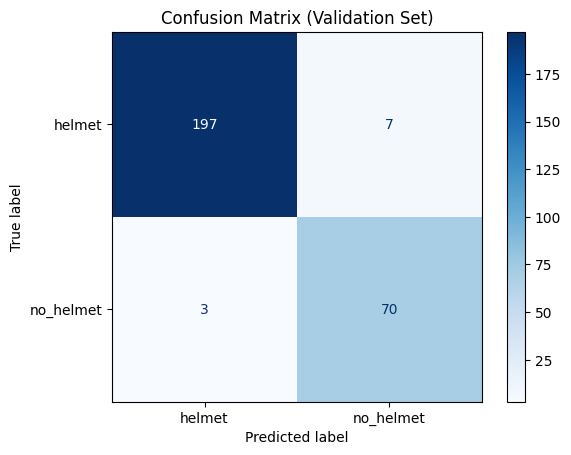

Saved → confusion_matrix.png


In [ ]:
# Confusion matrix plot
cm   = confusion_matrix(all_true, all_pred_labels, labels=[1, 2])
disp = ConfusionMatrixDisplay(cm, display_labels=["helmet", "no_helmet"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrix.png")

In [ ]:
# Per-class metrics report
print("\n" + "="*45)
print("      PER CLASS RESULTS (Validation)")
print("="*45)
for cls_id, name in CLASS_NAMES.items():
    tp = class_tp[cls_id]
    fp = class_fp[cls_id]
    fn = class_fn[cls_id]
    tn = sum(class_tp[c] for c in CLASS_NAMES if c != cls_id)

    p         = tp / (tp + fp + 1e-6)
    r         = tp / (tp + fn + 1e-6)
    f         = 2 * p * r / (p + r + 1e-6)
    support   = tp + fn
    accuracy  = tp / (tp + fp + fn + 1e-6)
    fpr       = fp / (fp + tn + 1e-6)
    miss_rate = fn / (fn + tp + 1e-6)

    print(f"  [{name}]")
    print(f"    Precision      : {p:.3f}")
    print(f"    Recall         : {r:.3f}")
    print(f"    F1 Score       : {f:.3f}")
    print(f"    Accuracy       : {accuracy:.3f}")
    print(f"    False Pos Rate : {fpr:.3f}")
    print(f"    Miss Rate      : {miss_rate:.3f}")
    print(f"    Support        : {support} GT objects")
    print(f"    TP: {tp}  FP: {fp}  FN: {fn}")
    print("-"*45)


      PER CLASS RESULTS (Validation)
  [helmet]
    Precision      : 0.794
    Recall         : 0.891
    F1 Score       : 0.840
    Accuracy       : 0.724
    False Pos Rate : 0.421
    Miss Rate      : 0.109
    Support        : 221 GT objects
    TP: 197  FP: 51  FN: 24
---------------------------------------------
  [no_helmet]
    Precision      : 0.680
    Recall         : 0.729
    F1 Score       : 0.704
    Accuracy       : 0.543
    False Pos Rate : 0.143
    Miss Rate      : 0.271
    Support        : 96 GT objects
    TP: 70  FP: 33  FN: 26
---------------------------------------------


In [ ]:
# Overall summary
total_tp    = sum(class_tp.values())
total_fp    = sum(class_fp.values())
total_fn    = sum(class_fn.values())
overall_p   = total_tp / (total_tp + total_fp + 1e-6)
overall_r   = total_tp / (total_tp + total_fn + 1e-6)
overall_f1  = 2 * overall_p * overall_r / (overall_p + overall_r + 1e-6)
overall_acc = total_tp / (total_tp + total_fp + total_fn + 1e-6)

print("="*45)
print("        OVERALL SUMMARY (Validation)")
print("="*45)
print(f"  Precision : {overall_p:.3f}")
print(f"  Recall    : {overall_r:.3f}")
print(f"  F1 Score  : {overall_f1:.3f}")
print(f"  Accuracy  : {overall_acc:.3f}")
print(f"  TP: {total_tp}  FP: {total_fp}  FN: {total_fn}")
print("="*45)

        OVERALL SUMMARY (Validation)
  Precision : 0.761
  Recall    : 0.842
  F1 Score  : 0.799
  Accuracy  : 0.666
  TP: 267  FP: 84  FN: 50


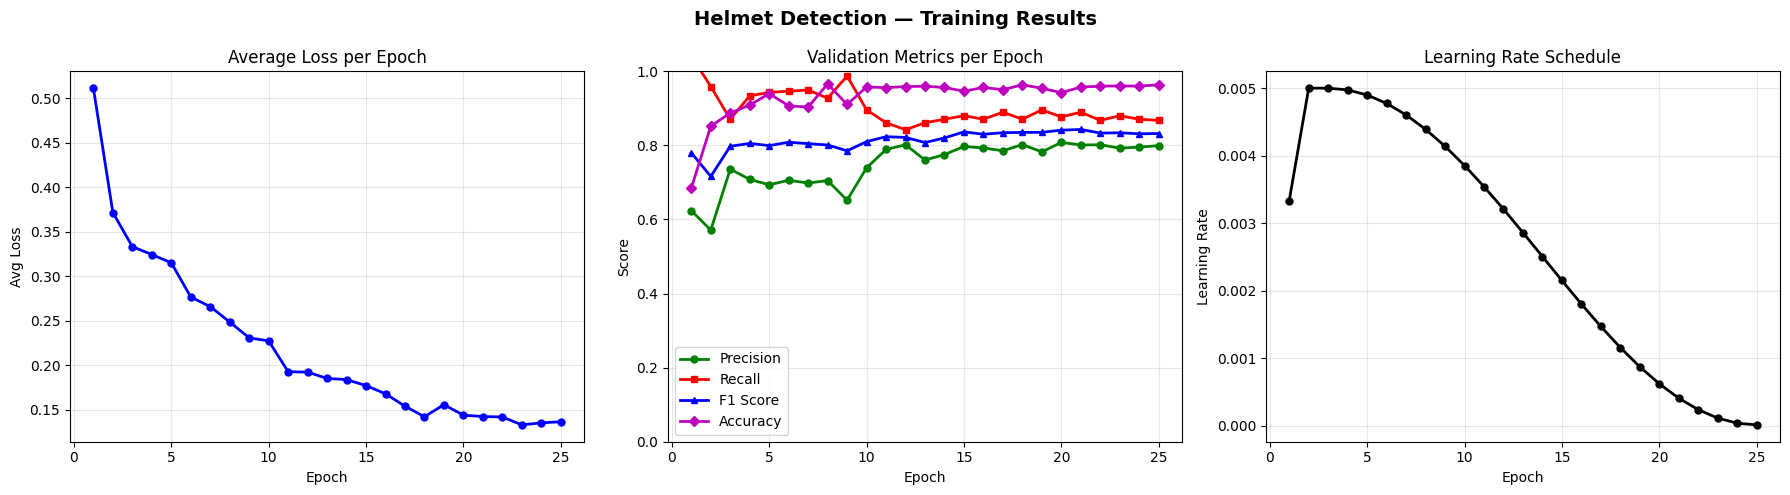

Saved → training_results.png


In [ ]:
## TRAINING CURVES

epochs = list(range(1, len(history["loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Helmet Detection — Training Results", fontsize=14, fontweight="bold")

# Plot 1: Average loss per epoch
axes[0].plot(epochs, history["avg_loss"], "b-o", linewidth=2, markersize=5)
axes[0].set_title("Average Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Avg Loss")
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation metrics (precision, recall, F1, accuracy)
axes[1].plot(epochs, history["precision"], "g-o", linewidth=2, markersize=5, label="Precision")
axes[1].plot(epochs, history["recall"],    "r-s", linewidth=2, markersize=5, label="Recall")
axes[1].plot(epochs, history["f1"],        "b-^", linewidth=2, markersize=5, label="F1 Score")
axes[1].plot(epochs, history["accuracy"],  "m-D", linewidth=2, markersize=5, label="Accuracy")
axes[1].set_title("Validation Metrics per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Learning rate schedule (shows warmup ramp + cosine decay)
axes[2].plot(epochs, history["lr"], "k-o", linewidth=2, markersize=5)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → training_results.png")

## Test Set Validation

In [ ]:
print("\n── Test Set Evaluation ──────────────────────────────")

test_metric     = MeanAveragePrecision(iou_type="bbox")
test_iou_scores = []
test_tp         = 0
test_pred       = 0
test_gt         = 0

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds  = model(images)

        for pred, target in zip(preds, targets):
            keep    = pred["scores"] >= SCORE_THRESH
            p_boxes = pred["boxes"][keep].cpu()
            g_boxes = target["boxes"].cpu()

            test_pred += len(p_boxes)
            test_gt   += len(g_boxes)

            if len(p_boxes) > 0 and len(g_boxes) > 0:
                iou_mat  = box_iou(p_boxes, g_boxes)
                best_iou = iou_mat.max(dim=1).values
                test_iou_scores.extend(best_iou.tolist())
                test_tp += (best_iou >= IOU_THRESH).sum().item()

        # Update mAP metric with this batch
        test_metric.update(
            [{"boxes": p["boxes"].cpu(), "scores": p["scores"].cpu(),
              "labels": p["labels"].cpu()} for p in preds],
            [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()}
             for t in targets]
        )

test_results  = test_metric.compute()
test_avg_iou  = sum(test_iou_scores) / (len(test_iou_scores) + 1e-6)
test_prec     = test_tp / (test_pred + 1e-6)
test_rec      = test_tp / (test_gt   + 1e-6)
test_f1       = 2 * test_prec * test_rec / (test_prec + test_rec + 1e-6)

print("="*45)
print("           TEST SET RESULTS")
print("="*45)
print(f"  mAP@0.50       : {test_results['map_50'].item():.4f}  ({test_results['map_50'].item()*100:.1f}%)")
print(f"  mAP@0.75       : {test_results['map_75'].item():.4f}  ({test_results['map_75'].item()*100:.1f}%)")
print(f"  mAP@0.50:0.95  : {test_results['map'].item():.4f}  ({test_results['map'].item()*100:.1f}%)")
print(f"  Average IoU    : {test_avg_iou:.4f}  ({test_avg_iou*100:.1f}%)")
print(f"  Precision      : {test_prec:.3f}")
print(f"  Recall         : {test_rec:.3f}")
print(f"  F1 Score       : {test_f1:.3f}")
print("="*45)


── Test Set Evaluation ──────────────────────────────
           TEST SET RESULTS
  mAP@0.50       : 0.7649  (76.5%)
  mAP@0.75       : 0.5236  (52.4%)
  mAP@0.50:0.95  : 0.4706  (47.1%)
  Average IoU    : 0.6471  (64.7%)
  Precision      : 0.784
  Recall         : 0.923
  F1 Score       : 0.848


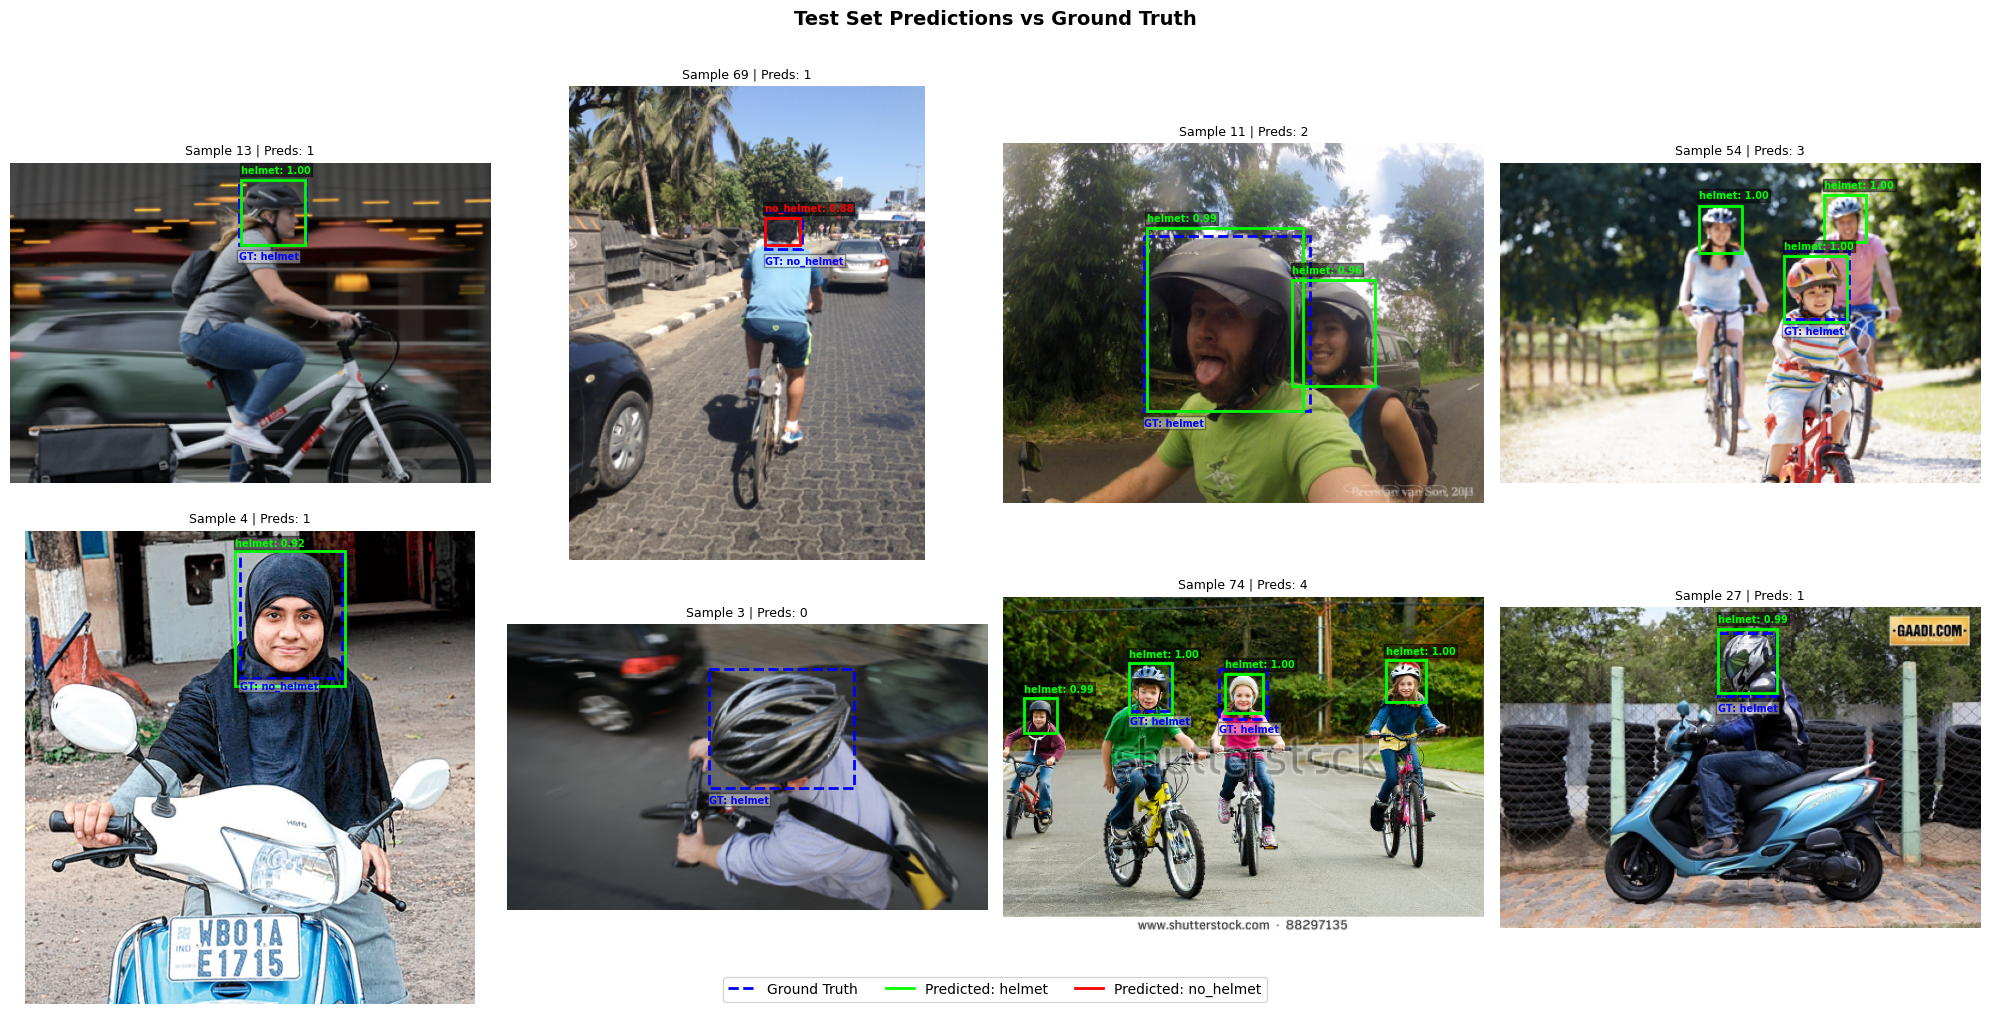

✅ Saved → test_predictions.png


In [ ]:
## VISUALISE PREDICTIONS ON TEST SET

def predict_and_show(dataset, num_samples=8, threshold=SCORE_THRESH,
                     save_path="test_predictions.png"):
    """
    Randomly picks num_samples images, runs inference, and plots
    ground truth boxes (blue dashed) vs predictions (colored solid).

    Args:
        dataset    : SubsetDataset — use test_ds
        num_samples: how many images to visualise
        threshold  : confidence score cutoff for showing predictions
        save_path  : filename to save the figure
    """
    samples = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for ax_idx, sample_idx in enumerate(samples):
        # Get original PIL image (before transforms) for display
        img_pil, target = dataset.base[dataset.indices[sample_idx]]

        # Normalize the PIL image before passing to the model
        tensor = TF.to_tensor(img_pil)
        tensor = TF.normalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        with torch.no_grad():
            output = model(tensor.unsqueeze(0).to(device))[0]

        ax = axes[ax_idx]
        ax.imshow(img_pil)

        # Ground truth boxes — blue dashed outline
        for box, label in zip(target["boxes"], target["labels"]):
            x1, y1, x2, y2 = box.numpy()
            name = CLASSES[label.item()] if label.item() < len(CLASSES) else "unknown"
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="blue", facecolor="none", linestyle="--"
            )
            ax.add_patch(rect)
            ax.text(x1, y2 + 12, f"GT: {name}", color="blue", fontsize=7,
                    fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.4, pad=1))

        # Predicted boxes — solid, colored by class
        pred_count = 0
        for box, label, score in zip(output["boxes"], output["labels"], output["scores"]):
            if score < threshold:
                continue
            pred_count += 1
            x1, y1, x2, y2 = box.cpu().numpy()
            name  = CLASSES[label.item()] if label.item() < len(CLASSES) else "unknown"
            color = BOX_COLORS.get(name, "yellow")
            rect  = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 6, f"{name}: {score:.2f}", color=color,
                    fontsize=7, fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

        ax.set_title(f"Sample {sample_idx} | Preds: {pred_count}", fontsize=9)
        ax.axis("off")

    # Hide unused axes in the final row
    for i in range(len(samples), len(axes)):
        axes[i].axis("off")

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="blue", linewidth=2, linestyle="--", label="Ground Truth"),
        Line2D([0], [0], color="lime", linewidth=2,                 label="Predicted: helmet"),
        Line2D([0], [0], color="red",  linewidth=2,                 label="Predicted: no_helmet"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=3, fontsize=10, bbox_to_anchor=(0.5, 0.01))

    plt.suptitle("Test Set Predictions vs Ground Truth",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


predict_and_show(test_ds, num_samples=8, threshold=SCORE_THRESH)

## Save and Download Model

In [ ]:
from google.colab import drive, files
import os, shutil, torch

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Create folder
SAVE_DIR = "/content/drive/MyDrive/helmet_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 3. Paths
best_src  = "helmet_model_best.pth"   # already saved during training
final_src = "helmet_model_final.pth"  # may not exist yet

best_dst  = os.path.join(SAVE_DIR, "helmet_model_best.pth")
final_dst = os.path.join(SAVE_DIR, "helmet_model_final.pth")

# 4. Copy BEST model (IMPORTANT)
if os.path.exists(best_src):
    shutil.copy(best_src, best_dst)
    print("✅ Best model copied to Drive")
else:
    print("❌ Best model not found")

# 5. Save FINAL model now (since you didn’t save it before)
torch.save(model.state_dict(), final_src)
print("✅ Final model saved locally")

# 6. Copy FINAL to Drive
shutil.copy(final_src, final_dst)
print("✅ Final model copied to Drive")

# 7. Optional: download to your laptop
files.download(best_src)
files.download(final_src)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Best model copied to Drive
✅ Final model saved locally
✅ Final model copied to Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>